# Inspect a generated scene

Sanity-checking one scene at a time: build it, look at the numbers, plot the cloud and
the seam curves.

**This notebook reads `configs/playground.yaml` and follows its flags** — Phase 6a
(yaw, polygon outlines, D31 class disjointness), grooved butt preparations (D35/D36),
and the curved D29 families (uncomment `seam_families` in the config to switch the
whole notebook to the curved pipeline; every cell branches on it).

Run from the repo root (`weld_generator/`).

In [43]:
import sys, numpy as np
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/

from weldgen.config import load_config
from weldgen.scene import SceneRejected, generate_scene
from weldgen.scene_curved import generate_curved_scene

SEED_NUMBER = 134

cfg = load_config("../configs/playground.yaml")
CURVED = bool(cfg.get("seam_families"))       # D29 curve-first families
gen = generate_curved_scene if CURVED else generate_scene

# Phase 6 acceptance gates (D28 yaw feasibility, D31 disjointness, curved rediscovery
# and the D34 chord gate) mean a seed is not guaranteed to emit — walk forward until
# one does, and say why the others died. That IS the policy in action.
scene = arrays = None
for seed in range(SEED_NUMBER, SEED_NUMBER + 80):
    try:
        scene, arrays = gen(cfg, seed)
        break
    except SceneRejected as e:
        print(f"  seed {seed} omitted - {type(e).__name__}")
assert scene is not None, "no emitting seed in 80 tries - widen the budget"

j = scene["joint"]
print("\nscene_id ", scene["scene_id"], f" (seed {seed})")
print("twin_key ", scene["twin_key"])
print("joint    ", j["type"], "| quality", j["quality_level"],
      "| ISO 17659:", j.get("iso_17659_term"))
if CURVED:
    print("family   ", j["seam_family"], "| realization", j["realization"])
    print("chord err", f'{scene["cloud"]["max_chord_error_mm"]:.4f} mm',
          " (D34 gate: 0.25)")
else:
    print("prep     ", j.get("prep", "square"),
          "| ISO 9692 ref:", j.get("iso_9692_ref"))
    if j.get("groove"):
        print("groove   ", j["groove"])
    print("yaw      ", round(j.get("in_plane_yaw_deg") or 0.0, 2), "deg  (D28)")
    print("outlines ", {o["id"]: (o.get("outline_shape") or "rect")
                        for o in scene["objects"]})
    if j.get("ambiguous_with"):
        print("ambiguous", j["ambiguous_with"], " (D32 boundary stratum)")
print("included ", round(j["included_angle_deg"], 3), "deg")
print("root gap ", round(scene["fit"]["root_gap_mm"], 3), "mm")
print("points   ", scene["cloud"]["n_points"])


scene_id  4201b135-0000000134  (seed 134)
twin_key  0a55a755d0c70467
joint     butt | quality D | ISO 17659: butt joint (3.7)
prep      single_V | ISO 9692 ref: 1.3
groove    {'kind': 'single_V', 'groove_included_angle_deg': 58.69442432204799, 'bevel_deg_per_side': 29.347212161023997, 'root_face_mm': 1.3925317906739, 'radius_mm': None, 'iso_ref': '1.3'}
yaw       0.0 deg  (D28)
outlines  {'A': 'rect', 'B': 'rect'}
included  180.0 deg
root gap  1.282 mm
points    19984


## Seams

Weldable seams are the ground truth; everything else is kept **on purpose** as hard
negatives (D22). Phase 6 additions visible here:

* `dihedral_deg` is a scalar only when constant; on curved seams it varies point-to-point
  and the block carries `{min, max, mean}` backed by a per-sample array.
* curved seams carry `closed` (a circle has no endpoints) and `clear_fraction`
  (how much of the seam the torch cone actually clears — D13's bore gate).
* under D31 class disjointness, lap/edge configurations stop producing each other's
  seams by construction, and the underside lap toe gets its own label.

In [44]:
# Weldable seams are the ground truth. The rest are kept ON PURPOSE as hard negatives
# (D22): real geometry that a detector would return but that is not this joint's weld.
def _dih(s):
    d = s["dihedral_deg"]
    if isinstance(d, dict):                   # curved: it varies along the seam
        return f'{d["min"]:5.1f}..{d["max"]:5.1f}'
    return f'{d:6.2f}'

weld     = [s for s in scene["seams"] if s["weldable"]]
rejected = [s for s in scene["seams"] if not s["weldable"]]

print(f'{scene["joint"]["type"]} joint  ->  {len(weld)} weldable, {len(rejected)} rejected\n')
print("WELDABLE (ground truth)")
for s in weld:
    extra = "  closed" if s.get("closed") else ""
    if s.get("clear_fraction") is not None:
        extra += f'  clear={s["clear_fraction"]:.2f}'
    if s.get("underside"):
        extra += "  underside"
    print(f'  seam {s["id"]:>2}  {str(s["face_pair"]):<24} {s["seam_class"]:<8} '
          f'len={s["length_mm"]:8.2f} mm  dihedral={_dih(s)}{extra}')
print("\nREJECTED (negatives, not ground truth)")
for s in rejected:
    print(f'  seam {s["id"]:>2}  {str(s["face_pair"]):<24} {s["seam_class"]:<8} '
          f'len={s["length_mm"]:8.2f} mm  <- {s["reject_reason"]}')

butt joint  ->  2 weldable, 7 rejected

WELDABLE (ground truth)
  seam  0  ['A:+w', 'B:+w']         butt     len=  248.81 mm  dihedral=180.00
  seam  1  ['A:-w', 'B:-w']         butt     len=  248.81 mm  dihedral=180.00

REJECTED (negatives, not ground truth)
  seam  2  ['A:-w', 'B:fusion']     lap_toe  len=  248.81 mm  <- toe_of_centreline
  seam  3  ['A:-w', 'B:root']       lap_toe  len=  248.81 mm  <- toe_of_centreline
  seam  4  ['A:fusion', 'B:-w']     lap_toe  len=  248.81 mm  <- toe_of_centreline
  seam  5  ['A:fusion', 'B:fusion'] edge     len=  248.81 mm  <- bisector_blocked
  seam  6  ['A:fusion', 'B:root']   edge     len=  248.81 mm  <- degenerate_dihedral
  seam  7  ['A:root', 'B:-w']       lap_toe  len=  248.81 mm  <- toe_of_centreline
  seam  8  ['A:root', 'B:fusion']   edge     len=  248.81 mm  <- degenerate_dihedral


## Seam reference curves: D19 and D36

Three regimes, and the next cell detects which one this scene is in:

* **square plates (D19)** — the stored curve is `nominal`; `root` and `gap_mid` ship as
  derived arrays so the conversion is a subtraction, not a re-derivation. At a right
  angle the offsets are `0, g/2, g` — but that closed form does not survive a sampled
  included angle.
* **grooved plates (D36)** — the D19 triple is square-prep-only. A grooved centreline
  instead carries a single `groove_root` at exactly `t − c` below the top face (`c` =
  root face). On a single bevel the mouth centreline provably shifts off the root
  centre — which is exactly why the two curves are stored separately.
* **curved families** — no triple at all; each seam carries per-point frame arrays
  (`_tangent`, `_approach`, `_nA`, `_nB`) and a per-sample `_dihedral` array.

In [45]:
g = scene["fit"]["root_gap_mm"]
for s in weld:                        # negatives carry curves too, but they are not GT
    key = s["sampled"]["array"]
    nom = arrays[f"seams.npz:{key}"]
    if f"seams.npz:{key}_grooveroot" in arrays:            # D36: grooved centreline
        gr = arrays[f"seams.npz:{key}_grooveroot"]
        t = scene["objects"][0]["thickness_mm"]
        c = scene["joint"]["groove"]["root_face_mm"]
        depth = float(np.mean(nom[:, 2] - gr[:, 2]))
        # one root curve, two nominals: t - c below the TOP centreline, but c ABOVE
        # the underside one (the root face is the last c mm of the plate)
        exp = -c if s.get("underside") else t - c
        lateral = float(np.linalg.norm((nom - gr)[:, :2], axis=1).mean())
        side = "underside" if s.get("underside") else "top"
        print(f'seam {s["id"]} [{s["seam_class"]}, {side}]  groove_root: '
              f'depth = {depth:.4f} (expect {exp:.4f}), '
              f'lateral shift = {lateral:.4f} (> 0 iff single_bevel)')
    elif f"seams.npz:{key}_root" in arrays:                # D19: square-prep triple
        root = arrays[f"seams.npz:{key}_root"]
        mid = arrays[f"seams.npz:{key}_gapmid"]
        print(f'seam {s["id"]} [{s["seam_class"]}]:  '
              f'|root-nom| = {np.linalg.norm(root[0] - nom[0]):.4f}   '
              f'|mid-nom| = {np.linalg.norm(mid[0] - nom[0]):.4f}   (g = {g:.4f})')
    else:                                                  # curved: frames instead
        extras = sorted(k.rsplit(":", 1)[1][len(key):] for k in arrays
                        if k.startswith(f"seams.npz:{key}_"))
        print(f'seam {s["id"]} [{s["seam_class"]}]  curved - derived arrays: {extras}')

seam 0 [butt, top]  groove_root: depth = 3.5744 (expect 3.5744), lateral shift = 0.0000 (> 0 iff single_bevel)
seam 1 [butt, top]  groove_root: depth = -1.3925 (expect 3.5744), lateral shift = 0.0000 (> 0 iff single_bevel)


## Plot

**The scene is placed at a sampled world pose** (random yaw + translation, deliberately —
SCHEMA.md §1.1, so nothing about the joint leaks from the world axes).

* **Plate scenes**: `weldgen.viz.assembly_frame` undoes the pose, so the cross-section
  is the canonical drawing every time. The markers show whichever reference curves this
  scene actually stores — the D19 triple on square preps, `groove_root` on grooved ones.
* **Curved scenes**: there is no single cross-section plane, so the right-hand panel
  shows the per-sample dihedral along each weldable seam instead — the thing that is
  *constant* for plates and genuinely varies here (a tilted pipe sweeps tens of degrees).

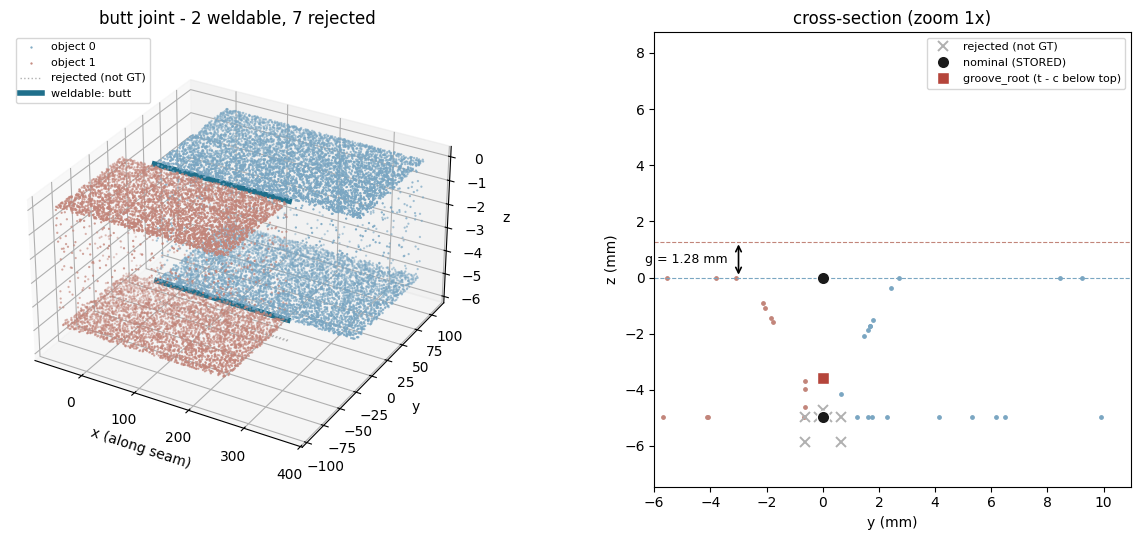

In [46]:
import matplotlib.pyplot as plt

# Rejected seams are kept in the file on purpose (D22) - real geometry that is NOT this
# joint's weld. Drawing them the same as ground truth is misleading, so they are pale
# and dashed here. Set SHOW_REJECTED = False to see the ground truth alone.
SHOW_REJECTED = True
ZOOM = 1          # plate cross-section only; ZOOM < 1 zooms in

CLASS_C = {"fillet": "#1a1a1a", "butt": "#1f6f8b", "lap_toe": "#8b5a1f",
           "edge": "#6b2f8b", "corner": "#4a6b1f"}

xyz_w = arrays["cloud.npz:xyz"]
oid = arrays["cloud.npz:object_id"]
fig = plt.figure(figsize=(13, 5.5))

if CURVED:
    # ---- 3D, world frame (curved scenes have no canonical assembly drawing) ------
    ax = fig.add_subplot(121, projection="3d")
    for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
        m = oid == o
        step = max(1, int(m.sum()) // 10000)
        ax.scatter(*xyz_w[m][::step].T, s=0.4, c=c, label=f"object {o}")
    if SHOW_REJECTED:
        for k, s in enumerate(rejected):
            q = arrays[f'seams.npz:{s["sampled"]["array"]}']
            ax.plot(*q.T, lw=1.0, ls=":", c="#b0b0b0",
                    label="rejected (not GT)" if k == 0 else None)
    seen = set()
    for s in weld:
        q = arrays[f'seams.npz:{s["sampled"]["array"]}']
        cl = s["seam_class"]
        ax.plot(*q.T, lw=4.0, c=CLASS_C.get(cl, "#1a1a1a"),
                label=None if cl in seen else f"weldable: {cl}")
        seen.add(cl)
    lo, hi = xyz_w.min(axis=0), xyz_w.max(axis=0)
    mid, span = 0.5 * (lo + hi), float((hi - lo).max())
    for k, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setter(mid[k] - 0.55 * span, mid[k] + 0.55 * span)
    ax.set_box_aspect([1, 1, 1]); ax.legend(loc="upper left", fontsize=8)
    ax.set_title(f'{scene["joint"]["seam_family"]}  '
                 f'({scene["joint"]["realization"]})', fontsize=10)

    # ---- dihedral along the seam: the quantity plates hold constant --------------
    ax2 = fig.add_subplot(122)
    for s in weld:
        d = arrays[f'seams.npz:{s["sampled"]["array"]}_dihedral']
        u = np.linspace(0.0, s["length_mm"], len(d))
        ax2.plot(u, d, lw=2, label=f'seam {s["id"]} [{s["seam_class"]}]')
    ax2.set_xlabel("arclength (mm)"); ax2.set_ylabel("dihedral (deg)")
    ax2.grid(alpha=0.3); ax2.legend(fontsize=8)
    ax2.set_title("per-sample dihedral (summarised as {min,max,mean} in scene.json)")
else:
    from weldgen.viz import assembly_frame, cross_section, to_assembly

    T = assembly_frame(scene)                    # world -> assembly
    xyz = to_assembly(xyz_w, T)
    g = scene["fit"]["root_gap_mm"]
    t_B = next(o for o in scene["objects"] if o["id"] == "B")["thickness_mm"]

    # ---- 3D ----------------------------------------------------------------------
    ax = fig.add_subplot(121, projection="3d")
    for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
        m = oid == o
        ax.scatter(xyz[m, 0], xyz[m, 1], xyz[m, 2], s=0.4, c=c, label=f"object {o}")
    if SHOW_REJECTED:
        for k, s in enumerate(rejected):
            q = to_assembly(arrays[f'seams.npz:{s["sampled"]["array"]}'], T)
            ax.plot(q[:, 0], q[:, 1], q[:, 2], lw=1.0, ls=":", c="#b0b0b0",
                    label="rejected (not GT)" if k == 0 else None)
    seen = set()
    for s in weld:
        q = to_assembly(arrays[f'seams.npz:{s["sampled"]["array"]}'], T)
        cl = s["seam_class"]
        ax.plot(q[:, 0], q[:, 1], q[:, 2], lw=4.0, c=CLASS_C.get(cl, "#1a1a1a"),
                label=None if cl in seen else f"weldable: {cl}")
        seen.add(cl)
    ax.set_box_aspect([1, 1, 0.6]); ax.legend(loc="upper left", fontsize=8)
    ax.set_xlabel("x (along seam)"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(f'{scene["joint"]["type"]} joint - {len(weld)} weldable, '
                 f'{len(rejected)} rejected')

    # ---- cross-section, zoomed on the joint --------------------------------------
    ax2 = fig.add_subplot(122)
    band = cross_section(xyz, half_width_mm=3.0)
    for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
        m = band & (oid == o)
        ax2.scatter(xyz[m, 1], xyz[m, 2], s=6, c=c)
    if SHOW_REJECTED:
        for k, s in enumerate(rejected):
            q = to_assembly(arrays[f'seams.npz:{s["sampled"]["array"]}'], T)
            ax2.plot(q[0, 1], q[0, 2], "x", ms=7, c="#b0b0b0", mew=1.4,
                     label="rejected (not GT)" if k == 0 else None, zorder=3)

    # markers follow whichever reference curves this scene stores (D19 vs D36)
    MARKS = {"": ("o", "#1a1a1a", "nominal (STORED)"),
             "_root": ("s", "#b5453b", "root"),
             "_gapmid": ("^", "#2f7d4f", "gap_mid"),
             "_grooveroot": ("s", "#b5453b", "groove_root (t - c below top)")}
    first = True
    for s in weld:                                  # ground truth only
        key = s["sampled"]["array"]
        for suf, (mk, c, lab) in MARKS.items():
            if f"seams.npz:{key}{suf}" not in arrays:
                continue
            q = to_assembly(arrays[f"seams.npz:{key}{suf}"], T)
            ax2.plot(q[0, 1], q[0, 2], mk, ms=9, c=c, mec="white", mew=1.0,
                     label=lab if first else None, zorder=5)
        first = False

    ax2.axhline(0.0, lw=0.8, ls="--", c="#7aa6c2")   # A top face
    ax2.axhline(g,   lw=0.8, ls="--", c="#c2857a")   # B bottom face
    ax2.annotate("", xy=(-3, 0), xytext=(-3, g),
                 arrowprops=dict(arrowstyle="<->", lw=1.2))
    ax2.text(-3.4, g / 2, f"g = {g:.2f} mm", ha="right", va="center", fontsize=9)

    pad = max(4.0 * g, 4.0)
    # grooved mouths open O(t): widen the window so the bevel walls are in frame
    if scene["joint"].get("groove"):
        pad = max(pad, 1.5 * scene["objects"][0]["thickness_mm"])
    x_lo, x_hi = -6.0, t_B + 6.0
    y_lo, y_hi = -pad, pad + g
    xc, yc = 0.5 * (x_lo + x_hi), 0.5 * (y_lo + y_hi)
    ax2.set_xlim(xc - ZOOM * (xc - x_lo), xc + ZOOM * (x_hi - xc))
    ax2.set_ylim(yc - ZOOM * (yc - y_lo), yc + ZOOM * (y_hi - yc))
    ax2.set_aspect("equal"); ax2.set_xlabel("y (mm)"); ax2.set_ylabel("z (mm)")
    ax2.legend(loc="upper right", fontsize=8)
    ax2.set_title(f"cross-section (zoom {ZOOM:g}x)")
plt.tight_layout()

### Reading the plate cross-section

(Plate branch only.) The markers sit on the joint's reference curves:

* **nominal** (stored) on A's top face, `z = 0` — where the extended planes meet
* square prep: **gap_mid** at `z = g/2` and **root** at `z = g` — the spread is `O(g)`,
  which at the reference 1,1 mm gap is larger than the ~0,6 mm RMSE the literature
  reports. That is the whole reason D19 exists.
* grooved prep: a single **groove_root** at `z = −(t − c)` — the bottom of the
  preparation, `O(t)` below the mouth, an order of magnitude beyond the D19 spread.
  Which curve a method is scored against is now a *choice the file makes explicit*.

In [47]:
# What the D19 triple means depends on the seam class:
#   fillet / lap_toe  - the faces meet at an angle, so nominal / gap_mid / root are three
#                       distinct curves offset by 0, g/2, g.
#   butt / edge       - the seam IS the gap centreline, so `nominal` and `gap_mid`
#                       coincide and `root` is the nearer face edge at g/2. The triple
#                       degenerates, which is correct, not a bug.
# The triple exists only on square-prep plate scenes (D36) - elsewhere this cell has
# nothing to check and says so.
if CURVED:
    print("curved scene - no D19 triple (see the derived-arrays listing above)")
elif scene["joint"]["prep"] != "square":
    print(f'grooved scene ({scene["joint"]["prep"]}) - the triple is replaced by '
          f'groove_root (D36), checked above')
else:
    for s in weld:
        i, cl = s["id"], s["seam_class"]
        key = s["sampled"]["array"]
        n = to_assembly(arrays[f"seams.npz:{key}"], T)[0]
        r = to_assembly(arrays[f"seams.npz:{key}_root"], T)[0]
        m = to_assembly(arrays[f"seams.npz:{key}_gapmid"], T)[0]
        if cl in ("butt", "edge"):
            exp = f"centreline: gap_mid == nominal (0), root = g/2 = {g/2:.4f}"
        else:
            exp = f"angled: gap_mid = g/2 = {g/2:.4f}, root = g = {g:.4f}"
        print(f'seam {i} {tuple(s["face_pair"])} [{cl}]')
        print(f'    |gap_mid - nominal| = {np.linalg.norm(m - n):7.4f}')
        print(f'    |root    - nominal| = {np.linalg.norm(r - n):7.4f}     expect {exp}')

grooved scene (single_V) - the triple is replaced by groove_root (D36), checked above


## Determinism

The Phase 1 gate (D15). The content hash is defined on *content*, not file bytes —
`np.savez` embeds zip timestamps, so byte-identity is unachievable.

In [48]:
from weldgen.hashing import content_hash

# `gen` and `seed` come from the first cell, so this checks whichever pipeline
# (plate or curved) actually produced the scene above.
a = content_hash(*gen(cfg, seed))
b = content_hash(*gen(cfg, seed))
print(a)
print("repeatable:", a == b)

# provenance is excluded, so re-running next month still matches
sc, ar = gen(cfg, seed)
sc["provenance"]["created_utc"] = "1999-01-01T00:00:00Z"
print("provenance-independent:", content_hash(sc, ar) == a)

ffd43224e0fd28b1b7b8c0bdeaac53eb3fb05dcd2dde7fa06e00028d3d15f534
repeatable: True
provenance-independent: True
